In [4]:
import cv2
from ultralytics import YOLO
import numpy as np
from pathlib import Path

model = YOLO('yolo_small_weights.pt')

def get_video_fight_score(video_path, sample_interval=10):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return 0.0
    confidences = []
    frame_count = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_count % sample_interval == 0:
            results = model(frame, verbose=False)
            for r in results:
                if r.boxes is not None:
                    for box in r.boxes:
                        cls = int(box.cls[0])
                        # Теперь ищем класс 'violence' (индекс 1)
                        if model.names[cls] == 'violence':
                            confidences.append(float(box.conf[0]))
        frame_count += 1
    cap.release()
    return np.mean(confidences) if confidences else 0.0

fight_dir = Path("C:/Users/user/datasets/my_videos/fight")
nonfight_dir = Path("C:/Users/user/datasets/my_videos/non_fight")

scores = []
for video_path in fight_dir.glob("*.*"):
    print(f"Обработка (fight): {video_path.name}")
    score = get_video_fight_score(str(video_path))
    scores.append((video_path.name, score, "fight"))
    print(f"  уверенность = {score:.3f}")
for video_path in nonfight_dir.glob("*.*"):
    print(f"Обработка (non_fight): {video_path.name}")
    score = get_video_fight_score(str(video_path))
    scores.append((video_path.name, score, "non_fight"))
    print(f"  уверенность = {score:.3f}")

print("\nПервые 10 результатов:")
for name, score, label in scores[:10]:
    print(f"{label:10} {score:.3f} {name}")

Обработка (fight): V_1.mp4
  уверенность = 0.841
Обработка (fight): V_10.mp4
  уверенность = 0.000
Обработка (fight): V_100.mp4
  уверенность = 0.559
Обработка (fight): V_1000.mp4
  уверенность = 0.554
Обработка (fight): V_101.mp4
  уверенность = 0.610
Обработка (fight): V_102.mp4
  уверенность = 0.607
Обработка (fight): V_103.mp4
  уверенность = 0.610
Обработка (fight): V_104.mp4
  уверенность = 0.542
Обработка (fight): V_105.mp4
  уверенность = 0.512
Обработка (fight): V_106.mp4
  уверенность = 0.540
Обработка (fight): V_107.mp4
  уверенность = 0.643
Обработка (fight): V_108.mp4
  уверенность = 0.596
Обработка (fight): V_109.mp4
  уверенность = 0.545
Обработка (fight): V_11.mp4
  уверенность = 0.531
Обработка (fight): V_110.mp4
  уверенность = 0.564
Обработка (fight): V_111.mp4
  уверенность = 0.677
Обработка (fight): V_112.mp4
  уверенность = 0.520
Обработка (fight): V_113.mp4
  уверенность = 0.581
Обработка (fight): V_114.mp4
  уверенность = 0.563
Обработка (fight): V_115.mp4
  уве

Всего видео с драками: 1000
Всего видео без драк: 1000


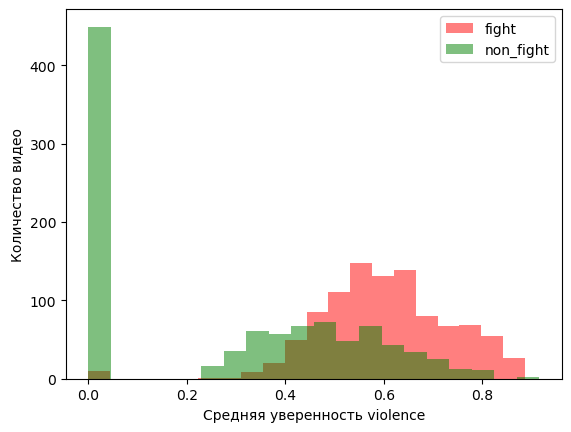

Оптимальный порог: 0.45
Точность на ваших видео: 78.8%


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Извлекаем уверенности для каждого класса
fight_scores = [s for _, s, l in scores if l == 'fight']
nonfight_scores = [s for _, s, l in scores if l == 'non_fight']

print(f"Всего видео с драками: {len(fight_scores)}")
print(f"Всего видео без драк: {len(nonfight_scores)}")

# Гистограммы
plt.hist(fight_scores, bins=20, alpha=0.5, label='fight', color='red')
plt.hist(nonfight_scores, bins=20, alpha=0.5, label='non_fight', color='green')
plt.xlabel('Средняя уверенность violence')
plt.ylabel('Количество видео')
plt.legend()
plt.show()

# Поиск оптимального порога
best_thresh = 0.0
best_acc = 0.0
for thresh in np.arange(0.0, 1.0, 0.01):
    tp = sum(1 for s in fight_scores if s >= thresh)
    tn = sum(1 for s in nonfight_scores if s < thresh)
    acc = (tp + tn) / len(scores)
    if acc > best_acc:
        best_acc = acc
        best_thresh = thresh

print(f"Оптимальный порог: {best_thresh:.2f}")
print(f"Точность на ваших видео: {best_acc*100:.1f}%")